In [1]:
# Author: Arthur Prigent
# Email: arthur.prigent@univ-brest.fr

In [2]:
import matplotlib.patches as mpatches
from scipy.stats import pearsonr
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy
import matplotlib
import scipy
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import matplotlib.colors as mcolors

from datetime import datetime, timedelta
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import glob
import matplotlib.pyplot as plt
import cmocean
import netCDF4
import string
import matplotlib.path as mpath
import ArcTools as Atools

# define boxes

In [3]:
import pandas as pd
import numpy as np

boxes = pd.read_csv('/home/aprigent/Documents/Projects/Analysis_obs/Arctic_design_10m_150_test_new.csv')



xc150 = np.array(([boxes["Longitude 1"].values,boxes["Longitude 2"].values,
                   boxes["Longitude 2"].values,boxes["Longitude 1"].values,boxes["Longitude 1"].values])).T
yc150 = np.array(([boxes["Latitude 1"].values,boxes["Latitude 1"].values,
                   boxes["Latitude 2"].values,boxes["Latitude 2"].values,boxes["Latitude 1"].values])).T
box_id = np.array(boxes["Box ID"].values)

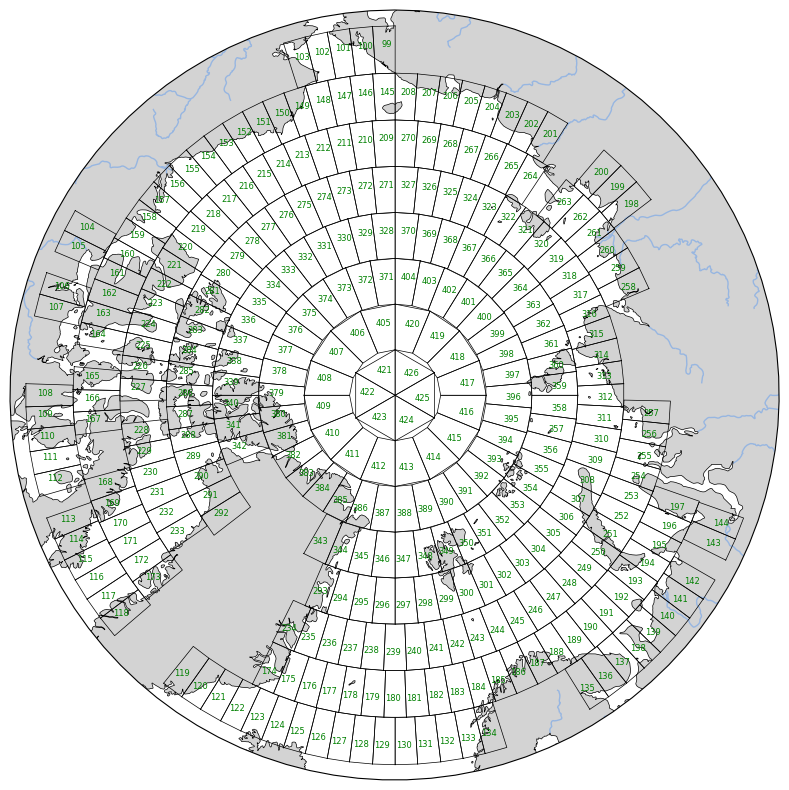

In [4]:
f,ax = plt.subplots(1,1,figsize=[10,10],subplot_kw={'projection':  ccrs.NorthPolarStereo()})
ftz=15


Atools.plot_arctic_ax_map_new(ax,gridlines=False)
for i in range(len(xc150)):
    if np.all(yc150[i] >= 65):
        ax.plot(xc150[i],yc150[i],'k',linewidth=.5, transform=ccrs.PlateCarree())
        ax.text(np.mean(xc150[i]),np.mean(yc150[i]),box_id[i], fontsize=6, color='g',transform=ccrs.PlateCarree(),va='center',ha='center')

# Load profiles

In [5]:
ds_profiles_unique_UDASH = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_UDASH_ISAS_TEMP_new.nc',decode_times=False)
ds_profiles_unique_ITP = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_ITP_ISAS_TEMP_new.nc',decode_times=False)
ds_profiles_unique_ARGO = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_ARGO_ISAS_TEMP_new.nc',decode_times=False)
ds_profiles_unique_NABOS = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_NABOS_ISAS_TEMP_new.nc',decode_times=False)
ds_profiles_unique_BGEP = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_BGEP_ISAS_TEMP_new.nc',decode_times=False)
ds_profiles_unique_MEOP = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_MEOP_ISAS_TEMP_new.nc',decode_times=False)
ds_profiles_unique_ICES = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_ICES_ISAS_TEMP_new.nc',decode_times=False)
ds_profiles_unique_CORA = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_CORA_ISAS_TEMP_new.nc',decode_times=False)
ds_profiles_unique_WOD = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_1/arctic_profile_WOD_ISAS_TEMP_new.nc',decode_times=False)

In [6]:
ds_all = xr.concat([ds_profiles_unique_UDASH,ds_profiles_unique_ITP,
                    ds_profiles_unique_ARGO,ds_profiles_unique_NABOS,
                    ds_profiles_unique_BGEP,ds_profiles_unique_MEOP,
                    ds_profiles_unique_ICES,
                    ds_profiles_unique_CORA,ds_profiles_unique_WOD,
                    ],dim='profile') # ds_profiles_unique_CORA,ds_profiles_unique_WODds_profiles_unique_MOS

In [7]:
ds_all['profile'] = np.arange(0,ds_all.longitude.shape[0],1)
ds_clean = np.array(ds_all.temperature.values)

# Make statistics per box

In [8]:
from matplotlib.path import Path
import numpy as np

profiles_in_box = {}

for i in range(len(xc150)):

    # build polygon for the box
    polygon = np.column_stack((xc150[i], yc150[i]))
    path = Path(polygon)

    # combine profile coordinates
    points = np.column_stack((ds_all.longitude.values, ds_all.latitude.values))

    # test which profiles fall inside
    inside = path.contains_points(points)

    # store indices of profiles inside the box
    profiles_in_box[box_id[i]] = np.where(inside)[0]
    print(f"Box {box_id[i]}: {len(profiles_in_box[box_id[i]])} profiles inside")
counts = [len(profiles_in_box[box_id[i]]) for i in range(len(box_id))]


Box 1: 0 profiles inside
Box 2: 0 profiles inside
Box 3: 0 profiles inside
Box 4: 0 profiles inside
Box 5: 0 profiles inside
Box 6: 0 profiles inside
Box 7: 0 profiles inside
Box 8: 0 profiles inside
Box 9: 0 profiles inside
Box 10: 0 profiles inside
Box 11: 0 profiles inside
Box 12: 0 profiles inside
Box 13: 0 profiles inside
Box 14: 0 profiles inside
Box 15: 0 profiles inside
Box 16: 0 profiles inside
Box 17: 0 profiles inside
Box 18: 0 profiles inside
Box 19: 0 profiles inside
Box 20: 0 profiles inside
Box 21: 0 profiles inside
Box 22: 0 profiles inside
Box 23: 0 profiles inside
Box 24: 0 profiles inside
Box 25: 0 profiles inside
Box 26: 0 profiles inside
Box 27: 0 profiles inside
Box 28: 0 profiles inside
Box 29: 0 profiles inside
Box 30: 0 profiles inside
Box 31: 0 profiles inside
Box 32: 0 profiles inside
Box 33: 0 profiles inside
Box 34: 0 profiles inside
Box 35: 0 profiles inside
Box 36: 0 profiles inside
Box 37: 0 profiles inside
Box 38: 0 profiles inside
Box 39: 0 profiles in

In [9]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="Degrees of freedom <= 0 for slice"
)
    
def plot_profiles_box(ds, mean, std, depth, box_id):

    f, ax = plt.subplots(1,1,figsize=[10,15])

    n_prof = ds.shape[0]

    ax.set_title(
        'Profiles in box ID ' + str(box_id) +
        ' | Number of profiles = ' + str(n_prof)
    )

    # flatten profiles for plotting
    x = ds.ravel()
    y = np.tile(depth, n_prof)

    ax.scatter(x, y, s=1, color='blue',label='Good data')

    # mean and sigma lines
    ax.plot(mean, depth, color='black', label=r'$\mu$')
    ax.plot(mean+std, depth, color='green', linestyle='--', label=r'$\mu + \sigma$')
    ax.plot(mean+2*std, depth, color='orange', linestyle='--', label=r'$\mu + 2\sigma$')
    ax.plot(mean+5*std, depth, color='red', linestyle='--', label=r'$\mu + 5\sigma$')

    ax.plot(mean-std, depth, color='green', linestyle='--', label=r'$\mu - \sigma$')
    ax.plot(mean-2*std, depth, color='orange', linestyle='--', label=r'$\mu - 2\sigma$')
    ax.plot(mean-5*std, depth, color='red', linestyle='--', label=r'$\mu - 5\sigma$')

    # broadcast mean/std to profile dimension
    mean2d = mean[None, :]
    std2d = std[None, :]

    # outliers
    bad_data = (ds > mean2d + 5*std2d) | (ds < mean2d - 5*std2d)

    # plot outliers
    ax.scatter(
        ds[bad_data],
        np.tile(depth, n_prof)[bad_data.ravel()],
        s=4,
        color='red',label='Outliers'
    )

    ax.invert_yaxis()
    ax.set_ylabel('Depth (m)')
    ax.set_xlabel('Salinity')
    ax.legend()

# Apply QC per box ID

In [10]:
def run_qc_pass_outlier(ds_clean, profiles_in_box, n_std1=5, n_std2=5, label="QC"):
    """
    Removes entire profiles if they contain outlier points.
    """

    bad_profiles = {}
    means = {}
    stds = {}

    ds_clean = ds_clean.copy()

    print(f'---- {label} ----')

    for bid, prof_idx in profiles_in_box.items():

        if len(prof_idx) == 0:
            continue

        ds_box = ds_clean[prof_idx, :]

        mean = np.nanmedian(ds_box, axis=0)
        std  = np.nanstd(ds_box, axis=0)

        # detect outlier points
        bad = (
            (ds_box > mean + n_std1 * std) |
            (ds_box < mean - n_std2 * std)
        )

        # profiles containing at least one bad point
        bad_prof_mask = np.any(bad, axis=1)

        n_removed = np.sum(bad_prof_mask)

        print(f"  Box {bid}: removed {n_removed} profiles")

        bad_profiles[bid] = prof_idx[bad_prof_mask]
        means[bid] = mean
        stds[bid] = std

        # remove entire profiles
        ds_clean[prof_idx[bad_prof_mask], :] = np.nan

    return ds_clean, bad_profiles, means, stds

ds_clean1, qc1_bad_points, qc1_mean, qc1_std = run_qc_pass_outlier(ds_clean, profiles_in_box, label="1st QC")
ds_clean2, qc2_bad_points, qc2_mean, qc2_std = run_qc_pass_outlier(ds_clean1, profiles_in_box, label="2nd QC")



---- 1st QC ----
  Box 58: removed 0 profiles
  Box 59: removed 0 profiles
  Box 60: removed 0 profiles
  Box 61: removed 0 profiles
  Box 64: removed 0 profiles
  Box 65: removed 0 profiles
  Box 66: removed 0 profiles
  Box 67: removed 0 profiles
  Box 69: removed 3 profiles
  Box 70: removed 0 profiles
  Box 71: removed 5 profiles
  Box 72: removed 0 profiles
  Box 73: removed 1 profiles
  Box 74: removed 0 profiles
  Box 76: removed 0 profiles
  Box 77: removed 1 profiles
  Box 78: removed 0 profiles
  Box 79: removed 0 profiles
  Box 80: removed 0 profiles
  Box 81: removed 0 profiles
  Box 82: removed 0 profiles
  Box 83: removed 0 profiles
  Box 84: removed 0 profiles
  Box 85: removed 4 profiles
  Box 86: removed 7 profiles
  Box 87: removed 12 profiles
  Box 88: removed 22 profiles
  Box 89: removed 13 profiles
  Box 90: removed 2 profiles
  Box 91: removed 3 profiles
  Box 92: removed 1 profiles
  Box 96: removed 0 profiles
  Box 97: removed 0 profiles
  Box 99: removed 0 pro

/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,
/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1095: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanmedian1d, axis, a, overwrite_input)


  Box 124: removed 20 profiles
  Box 125: removed 14 profiles
  Box 126: removed 57 profiles
  Box 127: removed 40 profiles
  Box 128: removed 36 profiles
  Box 129: removed 41 profiles
  Box 130: removed 30 profiles
  Box 131: removed 9 profiles
  Box 132: removed 13 profiles
  Box 133: removed 7 profiles
  Box 134: removed 4 profiles
  Box 135: removed 0 profiles
  Box 136: removed 0 profiles
  Box 137: removed 0 profiles
  Box 138: removed 0 profiles
  Box 139: removed 0 profiles
  Box 140: removed 0 profiles
  Box 142: removed 0 profiles
  Box 143: removed 0 profiles
  Box 144: removed 0 profiles
  Box 145: removed 0 profiles
  Box 146: removed 0 profiles
  Box 147: removed 0 profiles
  Box 148: removed 0 profiles
  Box 149: removed 0 profiles
  Box 150: removed 2 profiles
  Box 151: removed 14 profiles
  Box 152: removed 7 profiles
  Box 153: removed 6 profiles
  Box 154: removed 12 profiles
  Box 155: removed 21 profiles
  Box 156: removed 22 profiles
  Box 157: removed 7 profile

In [11]:
ds_qc = ds_all.copy()
ds_qc["temperature_QC"] = (("profile", "depth"), ds_clean2)
ds_qc

<xarray.Dataset>
Dimensions:          (profile: 370349, depth: 187)
Coordinates:
  * profile          (profile) int64 0 1 2 3 4 ... 370345 370346 370347 370348
  * depth            (depth) float64 1.0 3.0 5.0 ... 5.3e+03 5.4e+03 5.5e+03
Data variables:
    longitude        (profile) float64 26.25 3.528 3.03 ... -61.18 -61.19 -60.46
    latitude         (profile) float64 79.16 79.98 80.3 ... 66.6 66.6 66.67
    time             (profile) float64 7.23e+05 7.23e+05 ... 7.392e+05 7.392e+05
    source           (profile) object 'UDASH' 'UDASH' 'UDASH' ... 'WOD' 'WOD'
    dataset_index    (profile) float64 4.469e+03 4.47e+03 ... 6.163e+04
    is_duplicate     (profile) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    temperature      (profile, depth) float64 nan -1.105 -1.105 ... nan nan nan
    sum_temperature  (profile) float64 -102.0 46.5 -78.38 ... 8.67 -36.48 195.2
    sum_depth        (profile) float64 1.208e+04 2.466e+04 ... 1.318e+05
    nb_depth         (profile) float64 110.0 137.0 47.0 ... 118.0 93.0 511.0
    prof_descr       (profile) object b'ymer_1_S_schau' ... b'CA021192'
    temperature_QC   (profile, depth) float64 nan -1.105 -1.105 ... nan nan nan
Attributes:
    title:        ARGO temperature profiles
    source:       ARGO
    featureType:  profile
    Comments:     ARGO temperature profiles interpolated on ISAS vertical lev...

In [12]:
mask_valid = ~ds_qc.temperature_QC.isnull().all(dim="depth")
ds_qc = ds_qc.sel(profile=mask_valid)


In [13]:
# ds_qc.to_netcdf('/data0/user/aprigent/PROCESSED/level_2/profiles_QC_TEMP_new.nc')

In [14]:
# ds_qc = xr.open_dataset('/data0/user/aprigent/PROCESSED/level_2/profiles_QC_TEMP_new.nc')

In [15]:
# ds_profiles_unique_UDASH = ds_qc.where(ds_qc["source"]=='UDASH',drop=True)
# ds_profiles_unique_ITP = ds_qc.where(ds_qc["source"]=='ITP',drop=True)
# ds_profiles_unique_ARGO = ds_qc.where(ds_qc["source"]=='ARGO',drop=True)
# ds_profiles_unique_NABOS = ds_qc.where(ds_qc["source"]=='NABOS_ctd',drop=True)
# ds_profiles_unique_BGEP = ds_qc.where(ds_qc["source"]=='BGEP_ctd',drop=True)
# ds_profiles_unique_ICES = ds_qc.where(ds_qc["source"]=='ICES',drop=True)
# ds_profiles_unique_CORA = ds_qc.where(ds_qc["source"]=='CORA',drop=True)
# ds_profiles_unique_WOD = ds_qc.where(ds_qc["source"]=='WOD',drop=True)

# Apply QC per basin

In [16]:
def run_qc_pass_outlier_basin(ds_clean, profiles_in_box,
                              n_std1=5, n_std2=5, label="QC"):
    """
    Removes entire profiles if they contain outlier points.
    """

    bad_profiles = {}
    means = {}
    stds = {}

    ds_clean = ds_clean.copy()

    print(f'---- {label} ----')

    for bid, prof_idx in profiles_in_box.items():

        if len(prof_idx) == 0:
            continue

        ds_box = ds_clean[prof_idx, :]

        mean = np.nanmedian(ds_box, axis=0)
        std  = np.nanstd(ds_box, axis=0)

        # detect outlier points
        bad = (
            (ds_box > mean + n_std1 * std) |
            (ds_box < mean - n_std2 * std)
        )

        # profiles containing at least one outlier
        bad_prof_mask = np.any(bad, axis=1)

        n_removed = np.sum(bad_prof_mask)

        print(f"  Box {bid}: removed {n_removed} profiles")

        bad_profiles[bid] = prof_idx[bad_prof_mask]
        means[bid] = mean
        stds[bid] = std

        # remove entire profiles
        ds_clean[prof_idx[bad_prof_mask], :] = np.nan

    return ds_clean, bad_profiles, means, stds


In [17]:

ds_masks = xr.open_dataset('/data0/user/aprigent/mask_regions.nc')

# Interpolate basin mask to profile positions
basin_at_profiles = ds_masks.interp(
    lon=ds_qc.longitude % 360,
    lat=ds_qc.latitude,
    method="nearest"
)

In [18]:
profiles_in_basin = {}

for basin_name in basin_at_profiles.data_vars:
    mask = basin_at_profiles[basin_name].values

    # assume mask == 1 means inside basin
    prof_idx = np.where(mask == 1)[0]

    if len(prof_idx) > 0:
        profiles_in_basin[basin_name] = prof_idx

In [19]:


ds_clean_basin, qc1_bad_points_basin, qc1_mean_basin, qc1_std_basin = run_qc_pass_outlier_basin(ds_qc.temperature_QC.values, profiles_in_basin, label="QC per basin")


---- QC per basin ----


/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1095: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanmedian1d, axis, a, overwrite_input)


  Box AMERASIAN: removed 1661 profiles
  Box AMERASIAN_SHELF: removed 199 profiles
  Box SIBERIAN_SHELF: removed 17 profiles
  Box EURASIAN: removed 527 profiles
  Box NORDIC: removed 679 profiles
  Box BARENTS: removed 55 profiles
  Box KARA: removed 12 profiles
  Box GREEN_SHELF: removed 100 profiles
  Box BAFFIN: removed 153 profiles
  Box CANADA: removed 65 profiles


In [20]:
ds_qc_basin = ds_qc.copy()
ds_qc_basin["temperature_QC"] = (("profile", "depth"), ds_clean_basin)

mask_valid = ~ds_qc_basin.temperature.isnull().all(dim="depth")
ds_qc_basin = ds_qc_basin.sel(profile=mask_valid)

In [21]:
ds_qc_basin

<xarray.Dataset>
Dimensions:          (profile: 361904, depth: 187)
Coordinates:
  * profile          (profile) int64 0 1 2 3 4 ... 370345 370346 370347 370348
  * depth            (depth) float64 1.0 3.0 5.0 ... 5.3e+03 5.4e+03 5.5e+03
Data variables:
    longitude        (profile) float64 26.25 3.528 3.03 ... -61.18 -61.19 -60.46
    latitude         (profile) float64 79.16 79.98 80.3 ... 66.6 66.6 66.67
    time             (profile) float64 7.23e+05 7.23e+05 ... 7.392e+05 7.392e+05
    source           (profile) object 'UDASH' 'UDASH' 'UDASH' ... 'WOD' 'WOD'
    dataset_index    (profile) float64 4.469e+03 4.47e+03 ... 6.163e+04
    is_duplicate     (profile) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    temperature      (profile, depth) float64 nan -1.105 -1.105 ... nan nan nan
    sum_temperature  (profile) float64 -102.0 46.5 -78.38 ... 8.67 -36.48 195.2
    sum_depth        (profile) float64 1.208e+04 2.466e+04 ... 1.318e+05
    nb_depth         (profile) float64 110.0 137.0 47.0 ... 118.0 93.0 511.0
    prof_descr       (profile) object b'ymer_1_S_schau' ... b'CA021192'
    temperature_QC   (profile, depth) float64 nan -1.105 -1.105 ... nan nan nan
Attributes:
    title:        ARGO temperature profiles
    source:       ARGO
    featureType:  profile
    Comments:     ARGO temperature profiles interpolated on ISAS vertical lev...

In [22]:
ds_profiles_qc_UDASH = ds_qc_basin.where(ds_qc_basin["source"]=='UDASH',drop=True)
ds_profiles_qc_ITP = ds_qc_basin.where(ds_qc_basin["source"]=='ITP',drop=True)
ds_profiles_qc_ARGO = ds_qc_basin.where(ds_qc_basin["source"]=='ARGO',drop=True)
ds_profiles_qc_NABOS = ds_qc_basin.where(ds_qc_basin["source"]=='NABOS_ctd',drop=True)
ds_profiles_qc_BGEP = ds_qc_basin.where(ds_qc_basin["source"]=='BGEP_ctd',drop=True)
ds_profiles_qc_MEOP = ds_qc_basin.where(ds_qc_basin["source"]=='MEOP',drop=True)
ds_profiles_qc_ICES = ds_qc_basin.where(ds_qc_basin["source"]=='ICES',drop=True)
ds_profiles_qc_CORA = ds_qc_basin.where(ds_qc_basin["source"]=='CORA',drop=True)
ds_profiles_qc_WOD = ds_qc_basin.where(ds_qc_basin["source"]=='WOD',drop=True)


ds_profiles_qc_UDASH['profile'] = np.arange(0,ds_profiles_qc_UDASH.longitude.shape[0],1)
ds_profiles_qc_ITP['profile'] = np.arange(0,ds_profiles_qc_ITP.longitude.shape[0],1)
ds_profiles_qc_ARGO['profile'] = np.arange(0,ds_profiles_qc_ARGO.longitude.shape[0],1)
ds_profiles_qc_NABOS['profile'] = np.arange(0,ds_profiles_qc_NABOS.longitude.shape[0],1)
ds_profiles_qc_BGEP['profile'] = np.arange(0,ds_profiles_qc_BGEP.longitude.shape[0],1)
ds_profiles_qc_MEOP['profile'] = np.arange(0,ds_profiles_qc_MEOP.longitude.shape[0],1)
ds_profiles_qc_ICES['profile'] = np.arange(0,ds_profiles_qc_ICES.longitude.shape[0],1)
ds_profiles_qc_CORA['profile'] = np.arange(0,ds_profiles_qc_CORA.longitude.shape[0],1)
ds_profiles_qc_WOD['profile'] = np.arange(0,ds_profiles_qc_WOD.longitude.shape[0],1)



ds_profiles_qc_UDASH.to_netcdf('/data0/user/aprigent/PROCESSED/level_2/arctic_qc_UDASH_ISAS_TEMP_new2.nc')
ds_profiles_qc_ITP.to_netcdf('/data0/user/aprigent/PROCESSED/level_2/arctic_qc_ITP_ISAS_TEMP_new2.nc')
ds_profiles_qc_ARGO.to_netcdf('/data0/user/aprigent/PROCESSED/level_2/arctic_qc_ARGO_ISAS_TEMP_new2.nc')
ds_profiles_qc_NABOS.to_netcdf('/data0/user/aprigent/PROCESSED/level_2/arctic_qc_NABOS_ISAS_TEMP_new2.nc')
ds_profiles_qc_BGEP.to_netcdf('/data0/user/aprigent/PROCESSED/level_2/arctic_qc_BGEP_ISAS_TEMP_new2.nc')
ds_profiles_qc_MEOP.to_netcdf('/data0/user/aprigent/PROCESSED/level_2/arctic_qc_MEOP_ISAS_TEMP_new2.nc')
ds_profiles_qc_ICES.to_netcdf('/data0/user/aprigent/PROCESSED/level_2/arctic_qc_ICES_ISAS_TEMP_new2.nc')
ds_profiles_qc_CORA.to_netcdf('/data0/user/aprigent/PROCESSED/level_2/arctic_qc_CORA_ISAS_TEMP_new2.nc')
ds_profiles_qc_WOD.to_netcdf('/data0/user/aprigent/PROCESSED/level_2/arctic_qc_WOD_ISAS_TEMP_new2.nc')

In [23]:
ds_qc_basin.to_netcdf('/data0/user/aprigent/PROCESSED/level_2/profiles_QC_TEMP_new2.nc')

In [24]:
ds_masks = xr.open_dataset('/data0/user/aprigent/mask_regions.nc')

# Interpolate basin mask to profile positions
basin_at_profiles_qc = ds_masks.interp(
    lon=ds_qc_basin.longitude % 360,
    lat=ds_qc_basin.latitude,
    method="nearest"
)
ds_qc_basin_amerasian = ds_qc_basin.where(basin_at_profiles_qc.AMERASIAN==1,drop=True)

In [25]:
ds_masks = xr.open_dataset('/data0/user/aprigent/mask_regions.nc')

# Interpolate basin mask to profile positions
basin_at_profiles_qc = ds_masks.interp(
    lon=ds_all.longitude % 360,
    lat=ds_all.latitude,
    method="nearest"
)

ds_all_basin_amerasian = ds_all.where(basin_at_profiles_qc.AMERASIAN==1,drop=True)



In [26]:
ds_masks = xr.open_dataset('/data0/user/aprigent/mask_regions.nc')

# Interpolate basin mask to profile positions
basin_at_profiles_qc = ds_masks.interp(
    lon=ds_qc.longitude % 360,
    lat=ds_qc.latitude,
    method="nearest"
)

ds_qc_amerasian = ds_qc.where(basin_at_profiles_qc.AMERASIAN==1,drop=True)




In [27]:

   

def plot_vertical_distribution_test(ax, ds_psal):
    ftz = 15
    sal = ds_psal.values
    depth = ds_psal.depth.values
    n_prof_psal = sal.shape[0]

    finite_per_level_psal = np.sum(np.isfinite(sal), axis=0)
    psal_mean = np.nanmedian(sal, axis=0)
    psal_std = np.nanstd(sal, axis=0)

    # --- Fast scatter: flatten and drop NaNs before plotting ---
    sal_flat = sal.ravel()
    depth_flat = np.tile(depth, n_prof_psal)
    finite_mask = np.isfinite(sal_flat)
    ax.scatter(
        sal_flat[finite_mask],
        depth_flat[finite_mask],
        s=1,
        color='blue',
        alpha=0.3,
        rasterized=True,   # renders as bitmap, huge speedup for saving
        linewidths=0,       # skip edge drawing on each marker
    )

    ax.plot(psal_mean, depth, color='red', label=r'Median')
    ax.plot(psal_mean + psal_std, depth, 'g--', label=r'Median $\pm \sigma$')
    ax.plot(psal_mean - psal_std, depth, 'g--')
    ax.plot(psal_mean + 5*psal_std, depth, 'r--', label=r'Median $\pm 5\sigma$')
    ax.plot(psal_mean - 5*psal_std, depth, 'r--')

    ax.invert_yaxis()
    ax.set_ylim([3000, 0])
    ax.legend(fontsize=ftz)
    ax.set_xlabel("Temperature", fontsize=ftz)
    # ax.set_ylabel("Depth (m)", fontsize=ftz)
    ax.tick_params(labelsize=ftz) 

/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1095: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanmedian1d, axis, a, overwrite_input)
/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/opt/linux/envs/envs/phyocean-2022.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


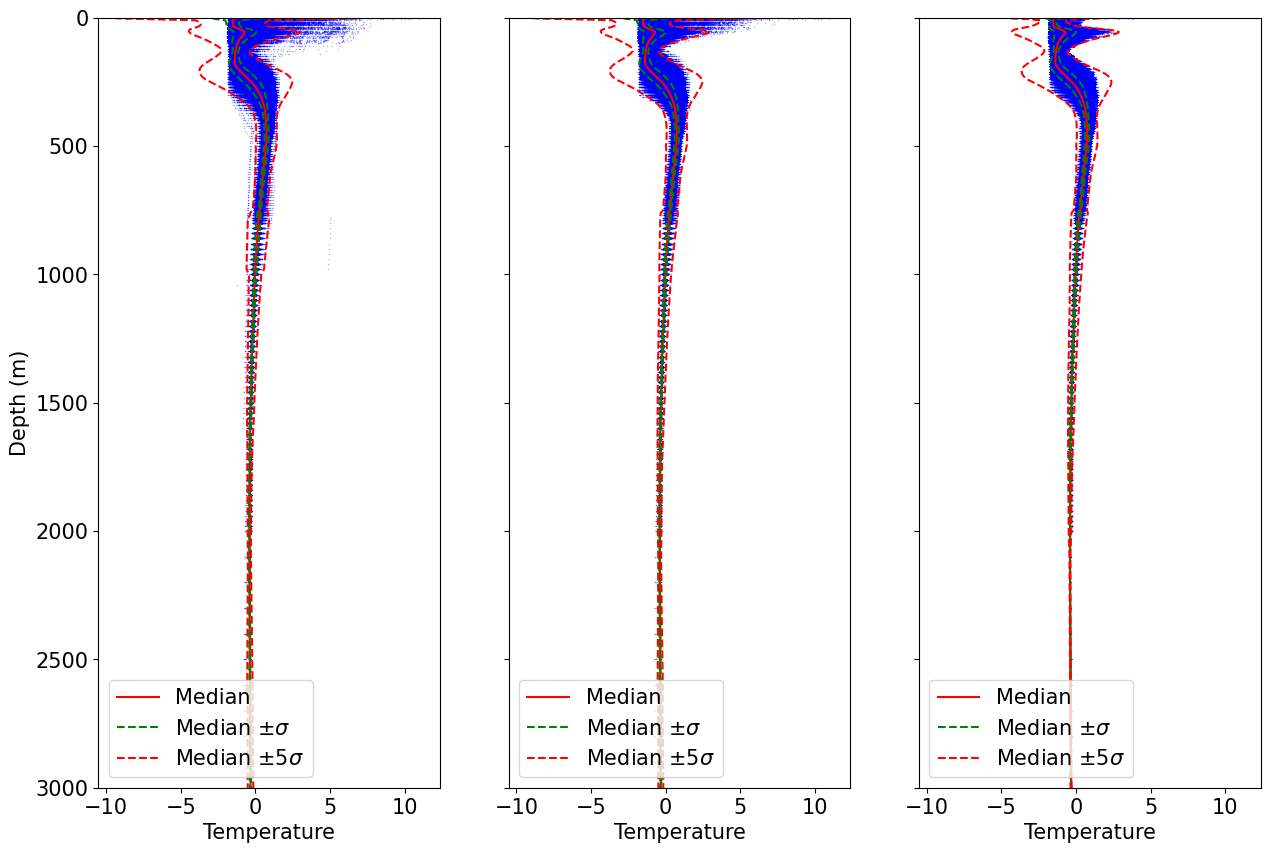

In [28]:
f,ax = plt.subplots(1,3,figsize=[15,10],sharex=True,sharey=True)
ax=ax.ravel()



plot_vertical_distribution_test(ax[0],ds_all_basin_amerasian.temperature)
ax[0].set_ylabel("Depth (m)", fontsize=ftz)
plot_vertical_distribution_test(ax[1],ds_qc_amerasian.temperature_QC)

plot_vertical_distribution_test(ax[2],ds_qc_basin_amerasian.temperature_QC)